**Matplotlib** is a powerful and widely-used Python library for creating static, animated, and interactive visualizations.


## 0. Setup and Imports
Before we begin, let's import the required libraries and set up the notebook to display plots inline. Remember that you only need to import a library once per file.

In [28]:
%pip install matplotlib pandas numpy

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# this Notebook magic function enables some visualization capabilities
%matplotlib inline 


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


If you get any errors from the `import` statements, you may need to install the libraries in your Notebook environment. `%pip` is a convenient "magic" Notebook function to install libraries for you.

In [29]:
%pip install pandas numpy matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Why Use Matplotlib?
- **Matplotlib** is the foundational plotting library in Python.
- It provides fine-grained control over every element of a plot.
- Integrates well with **NumPy** and **Pandas**.
- Other libraries (like **Seaborn**, **Pandas plotting**, and **Plotly**) often use Matplotlib under the hood.

**Use Matplotlib when:**
- You need complete control and customization.
- You're building publication-quality or print-ready charts.
- You want to integrate with the broader Python data science stack.

## 2. Anatomy of a Matplotlib Plot
A Matplotlib plot consists of multiple layers:
- **Figure**: The entire canvas.
- **Axes**: The area where the plot lives (not to be confused with x/y axes).
- **Axis**: x-axis and y-axis within each Axes.
- **Plot Elements**: lines, bars, titles, labels, annotations, legends, etc.



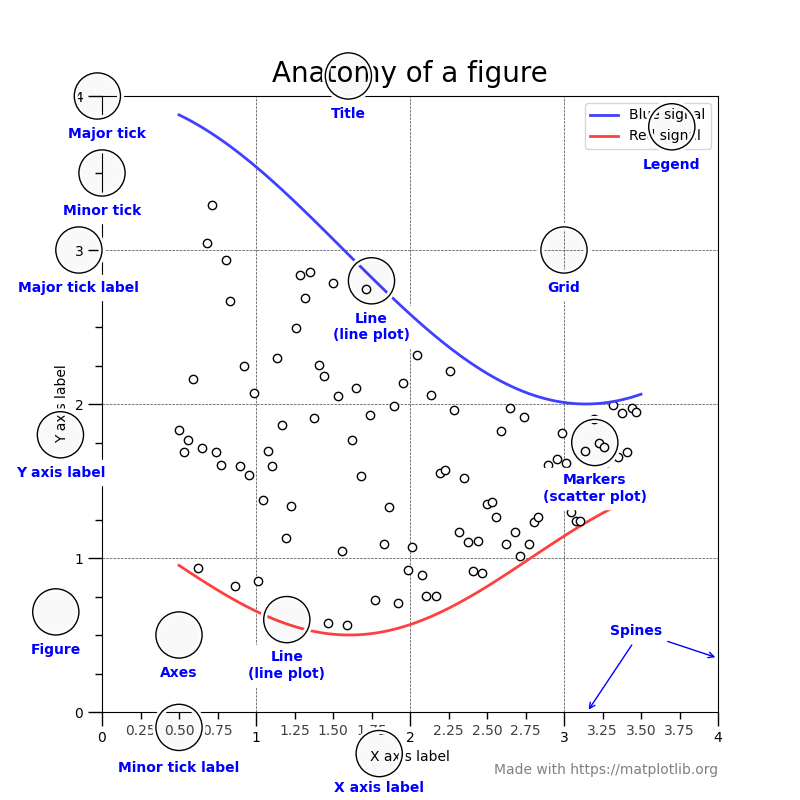


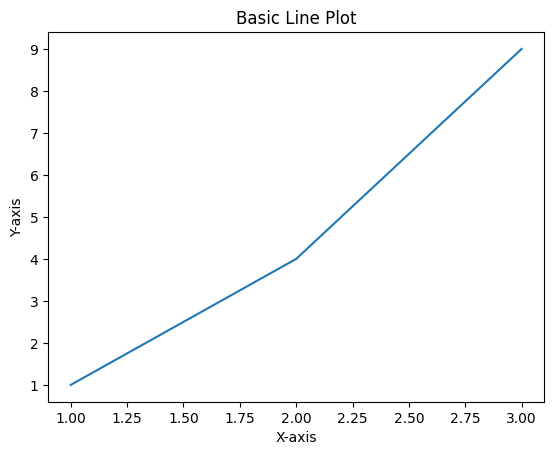

In [30]:
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [1, 4, 9])
ax.set_title("Basic Line Plot")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
plt.show()

## 3. Core Plot Types
Matplotlib supports many types of plots. Here we will focus on the most commonly used ones:
- Line Plot
- Bar Plot
- Scatter Plot
- Histogram
- Box Plot
- Pie Chart

Each plot type has unique strengths and is suited to specific types of data and analysis.

### 3.1 Line Plot
**Purpose:** To show trends, patterns, or changes over continuous intervals (e.g., time).

**Common Use Cases:**
- Stock prices over time
- Sensor readings
- Temperature or weather data
- Any kind of time series data

Line plots help identify trends, slopes, and periodic behaviors in data. They connect individual data points in a dataset through line segments, making them ideal for displaying trends and changes over time. They are particularly useful for time-series data analysis, showing how values evolve across different time intervals.

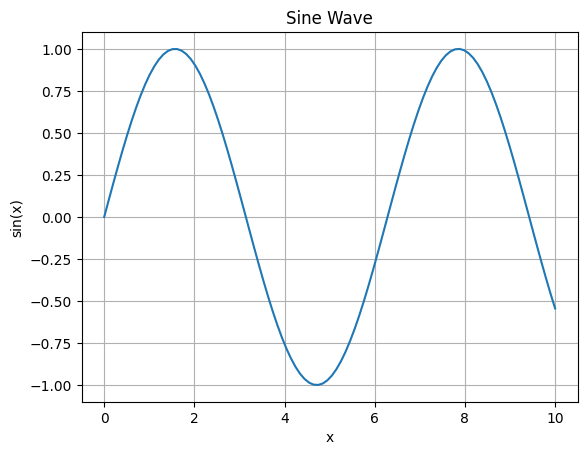

In [31]:
x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.plot(x, y)
plt.title("Sine Wave")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.grid(True)
plt.show()

### Use Case: Temperature Over Time

Let's load a file of data in CSV format using pandas to chart the temperature over time.

In [32]:
cols = [
    "Year", "Month",
    "Monthly_Anomaly", "Monthly_Unc",
    "Annual_Anomaly", "Annual_Unc",
    "FiveYear_Anomaly", "FiveYear_Unc",
    "TenYear_Anomaly", "TenYear_Unc",
    "TwentyYear_Anomaly", "TwentyYear_Unc",
]

data = pd.read_csv('Land_and_Ocean_complete.txt', comment="%", skipinitialspace=True, names=cols, sep=r"\s+", na_values="NaN")

data

,Year,Month,Monthly_Anomaly,Monthly_Unc,Annual_Anomaly,Annual_Unc,FiveYear_Anomaly,FiveYear_Unc,TenYear_Anomaly,TenYear_Unc,TwentyYear_Anomaly,TwentyYear_Unc
0,1850,1,-0.753,0.365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1850,2,-0.202,0.416,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1850,3,-0.367,0.373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1850,4,-0.596,0.324,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1850,5,-0.619,0.267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
4195,2024,8,1.257,0.032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4196,2024,9,1.138,0.036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4197,2024,10,1.182,0.042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4198,2024,11,1.169,0.057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
# Create a proper Date column

# 2025-07-31

data["Date"] = pd.to_datetime(data["Year"].astype(str) + "-" + data["Month"].astype(str).str.zfill(2))
data = data.sort_values("Date")

data['Date']

0      1850-01-01
2100   1850-01-01
2101   1850-02-01
1      1850-02-01
2      1850-03-01
          ...    
2097   2024-10-01
4198   2024-11-01
2098   2024-11-01
2099   2024-12-01
4199   2024-12-01
Name: Date, Length: 4200, dtype: datetime64[us]

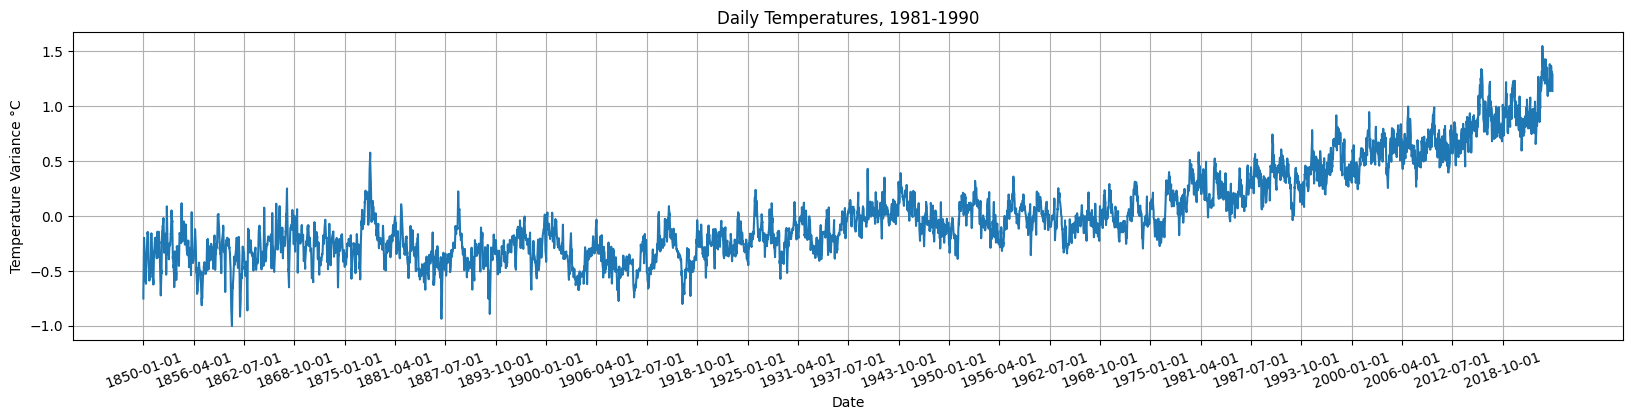

In [34]:
# Create the visualization

plt.figure(figsize=(20,4))
plt.title('Daily Temperatures, 1981-1990')
plt.plot(data['Date'], data['Monthly_Anomaly'])
plt.xlabel('Date')
plt.xticks(data['Date'][::150], rotation=20)
plt.ylabel('Temperature Variance °C')
plt.grid(True)
plt.show()

### 3.2 Bar Plot
**Purpose:** To compare quantities across discrete categories.

**Common Use Cases:**
- Sales per product category
- Number of users per age group
- Survey results by answer choice

Bar plots are excellent for highlighting which categories are larger or smaller relative to others.

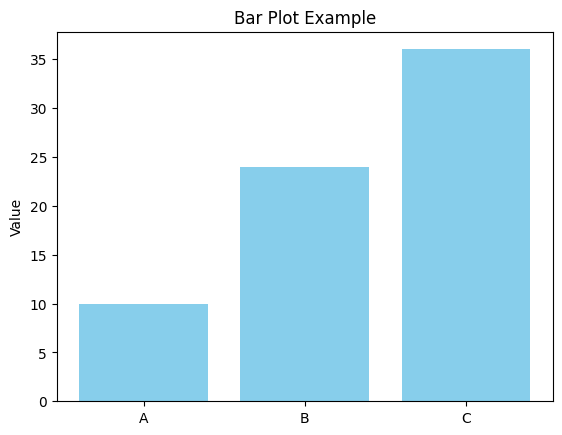

In [35]:
categories = ['A', 'B', 'C']
values = [10, 24, 36]

plt.bar(categories, values, color='skyblue')
plt.title("Bar Plot Example")
plt.ylabel("Value")
plt.show()

### Use Case: Electricity Mix by Country and Year

This dataset includes indicators such as the share of electricity generated from renewables and others by country over time.

In [36]:
data= pd.read_csv('https://github.com/owid/energy-data/raw/master/owid-energy-data.csv')

data

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>

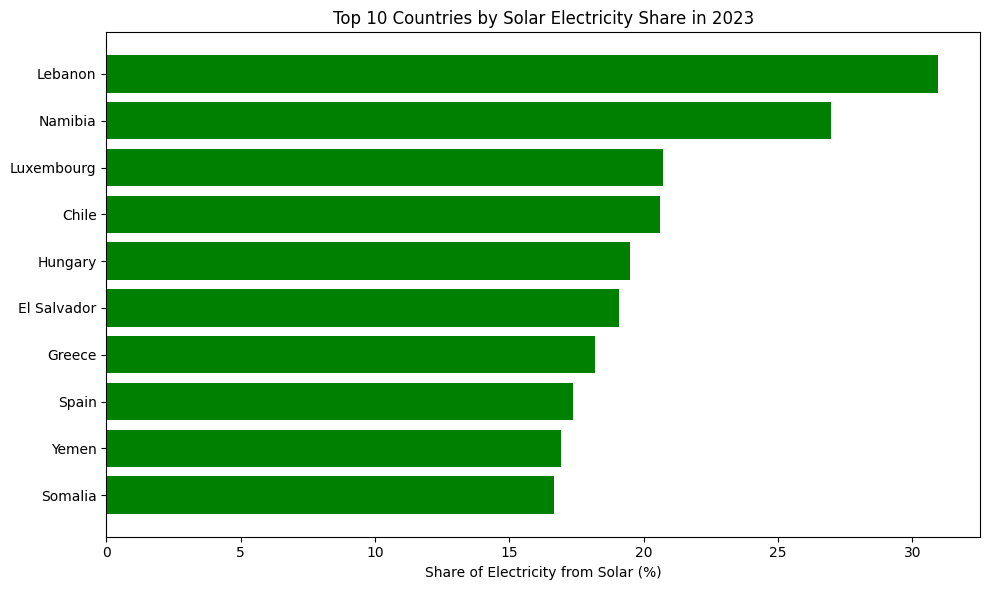

In [ ]:
# Filter for one year and only solar share by country
year = 2023
subset = data[data['year'] == year].dropna(subset=['solar_share_elec'])

# Sort and select top 10
top10 = subset.nlargest(10, 'solar_share_elec')

plt.figure(figsize=(10,6))
plt.barh(top10['country'], top10['solar_share_elec'], color='green')
plt.xlabel('Share of Electricity from Solar (%)')
plt.title(f'Top 10 Countries by Solar Electricity Share in {year}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 3.3 Scatterplot (Sometimes Called Bubble Plot)

**Purpose:** To show relationships or correlations between two continuous variables.

**Common Use Cases:**
- Height vs. weight of individuals
- Advertising spend vs. sales
- Biological measurements across samples (e.g., sepal width vs. length in the Iris dataset)

Scatterplots help you see clusters, outliers, and patterns. You can encode a third variable using color or size, creating a **Bubble Plot**. Scatterplots display the relationship between two continuous variables by plotting their values as coordinates in a two-dimensional space. This type of visualization is fundamental for observing correlations, trends, and potential clusters or outliers in data.

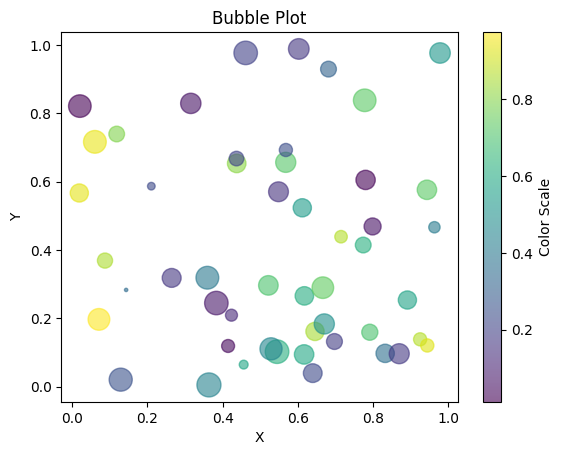

In [ ]:
np.random.seed(0)
x = np.random.rand(50)
y = np.random.rand(50)
sizes = 300 * np.random.rand(50)
colors = np.random.rand(50)

plt.scatter(x, y, s=sizes, c=colors, alpha=0.6)
plt.title("Bubble Plot")
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar(label='Color Scale')
plt.show()

Notice that in addition to the x/y coordinate position of each datapoint, we also have **color** and **size** to convey additional information about our datapoints. We will learn more about the different kinds of _encodings_ for marks in Week 2.

### Use Case: Life Expectancy vs. GDP Per Capita

In [ ]:
data = pd.read_csv("https://ourworldindata.org/grapher/life-expectancy-un-vs-gdp-per-capita-wb.csv?v=1&csvType=full", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

data

,Entity,Code,Year,Life expectancy,GDP per capita,Population,World region according to OWID
0,Afghanistan,AFG,1950,28.156,NaN,7776180.0,Asia
1,Afghanistan,AFG,1951,28.584,NaN,7879343.0,Asia
2,Afghanistan,AFG,1952,29.014,NaN,7987784.0,Asia
3,Afghanistan,AFG,1953,29.452,NaN,8096703.0,Asia
4,Afghanistan,AFG,1954,29.698,NaN,8207954.0,Asia
...,...,...,...,...,...,...,...
19190,Zimbabwe,ZWE,2020,61.530,4527.7197,15526887.0,Africa
19191,Zimbabwe,ZWE,2021,60.135,4827.0890,15797220.0,Africa
19192,Zimbabwe,ZWE,2022,62.360,5036.7610,16069061.0,Africa
19193,Zimbabwe,ZWE,2023,62.775,5218.0225,16340829.0,Africa


In [ ]:
data = data.rename(columns={"Life expectancy - Sex: all - Age: 0 - Variant: estimates": "Life Expectancy", "GDP per capita, PPP (constant 2021 international $)": "GDP"})


In [ ]:
subset = data[data['Year'] == 2023]
subset

,Entity,Code,Year,Life expectancy,GDP per capita,Population,World region according to OWID
73,Afghanistan,AFG,2023,66.035,1983.8126,4.145476e+07,Asia
147,Africa (UN),NaN,2023,63.843,NaN,1.480771e+09,NaN
221,Albania,ALB,2023,79.602,19487.7100,2.811660e+06,Europe
296,Algeria,DZA,2023,76.261,15159.3240,4.616422e+07,Africa
371,American Samoa,ASM,2023,72.852,NaN,4.754400e+04,Oceania
...,...,...,...,...,...,...,...
18895,Western Sahara,ESH,2023,71.385,NaN,5.797340e+05,Africa
18969,World,OWID_WRL,2023,73.169,20908.8480,8.091735e+09,NaN
19044,Yemen,YEM,2023,69.295,NaN,3.939080e+07,Asia
19118,Zambia,ZMB,2023,66.349,3673.4841,2.072397e+07,Africa


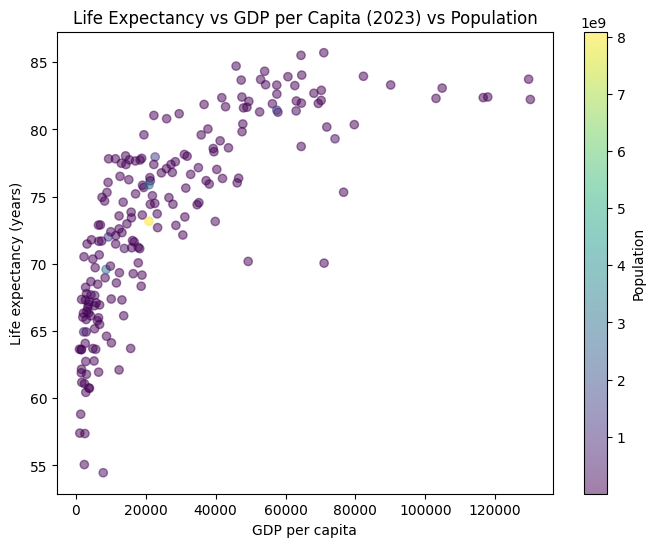

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(subset['GDP per capita'], subset['Life expectancy'], c=subset['Population'], alpha=0.5)
plt.xlabel('GDP per capita')
plt.ylabel('Life expectancy (years)')
plt.title(f'Life Expectancy vs GDP per Capita (2023) vs Population')
plt.colorbar(label='Population')
plt.show()

Does this visualization effectively show the relationships between life expectancy, GDP, and Population? Can we improve it?

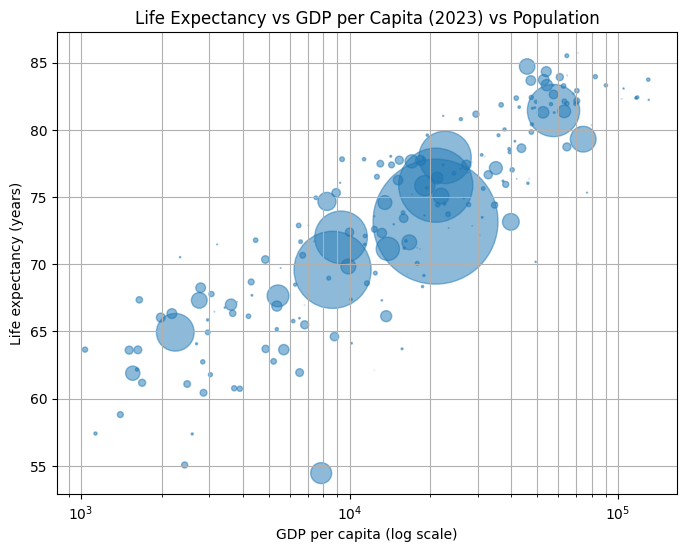

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(subset['GDP per capita'], subset['Life expectancy'], sizes=subset['Population'] / 1e6, alpha=0.5)
plt.xscale('log')  # GDP is better visualized on a log scale
plt.xlabel('GDP per capita (log scale)')
plt.ylabel('Life expectancy (years)')
plt.title(f'Life Expectancy vs GDP per Capita (2023) vs Population')
plt.grid(True, which='both')
plt.show()

### 3.4 Histogram
**Purpose:** To show the frequency distribution of a single continuous variable.

**Common Use Cases:**
- Distribution of exam scores
- Frequency of daily sales figures
- Residuals in regression models

Histograms reveal the shape of your data—whether it's normal, skewed, bimodal, etc. They are used to depict the distribution of a single continuous or discrete variable by segmenting data into bins and displaying the frequency of data points within each bin. They are essential for understanding the central tendency, dispersion, and skewness of data.

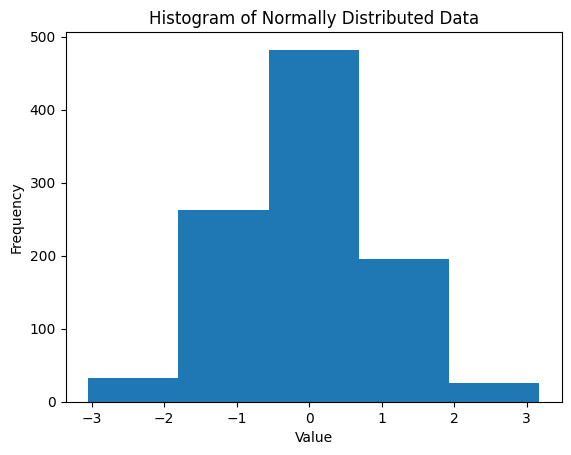

In [ ]:
data = np.random.randn(1000)
plt.hist(data, bins=5)
plt.title("Histogram of Normally Distributed Data")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

**Histograms** and **bar plots** are very similar visually but represent different ways of dealing with data. Bar plots are used to compare _across_ categories, whereas histograms are used for a single, continuous variable in _one_ category.

### Use Case: _Titanic_ Passenger Ages

Data from the _Titanic_ is often used as a good learning dataset. Let's plot the distribution of passenger ages with a histogram.

In [ ]:
data = pd.read_csv("titanic.csv")

data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


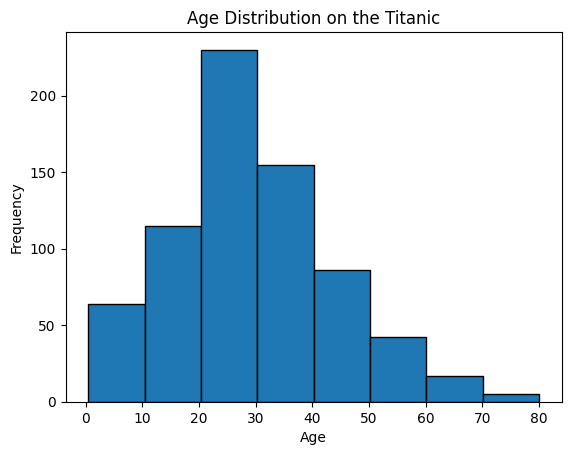

In [ ]:
plt.hist(data['Age'], bins=8, edgecolor='black')
plt.title("Age Distribution on the Titanic")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### 3.5 Box Plot
**Purpose:** To summarize the distribution of data through its quartiles and identify outliers.

**Common Use Cases:**
- Comparing test scores across classes
- Distribution of salaries across departments
- Comparing performance metrics across models

Box plots provide a visual summary using five-number statistics: minimum, Q1, median, Q3, and maximum. Outliers are shown as dots.

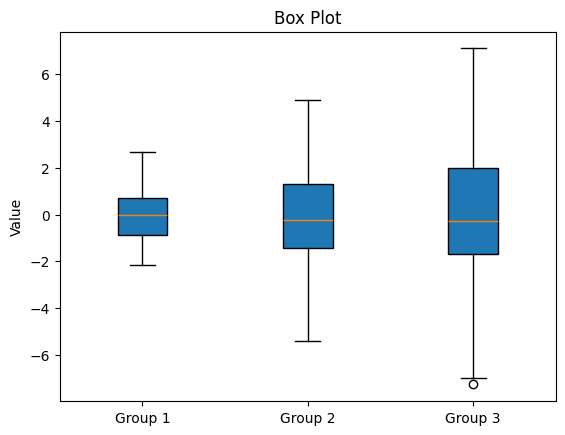

In [ ]:
data = [np.random.normal(0, std, 100) for std in range(1, 4)]
plt.boxplot(data, vert=True, patch_artist=True)
plt.title("Box Plot")
plt.xticks([1, 2, 3], ['Group 1', 'Group 2', 'Group 3'])
plt.ylabel("Value")
plt.show()

### Use Case: World Happiness by Region

In [ ]:
data = pd.read_csv("https://ourworldindata.org/grapher/happiness-vs-gdp-per-capita-time.csv?v=1&csvType=full", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

data


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1018)>

In [ ]:
print(data['World region according to OWID'].unique())
print(data)
print(data.head(100))

TypeError: list indices must be integers or slices, not str

In [ ]:
pd.set_option('display.max_rows', 100)
data.head(100)

,Entity,Code,Year,"Share who say they're ""happy"" or ""very happy"" (IVS)",GDP per capita,Population,World region according to OWID,"Share who say they're ""happy"" or ""very happy"" (IVS) (Annotations)"
0,Afghanistan,AFG,2000,NaN,1617.8264,20130334.0,Asia,NaN
1,Afghanistan,AFG,2001,NaN,1454.1108,20284303.0,Asia,NaN
2,Afghanistan,AFG,2002,NaN,1774.3087,21378123.0,Asia,NaN
3,Afghanistan,AFG,2003,NaN,1815.9282,22733053.0,Asia,NaN
4,Afghanistan,AFG,2004,NaN,1776.9182,23560656.0,Asia,NaN
5,Afghanistan,AFG,2005,NaN,1908.1147,24404575.0,Asia,NaN
6,Afghanistan,AFG,2006,NaN,1929.7239,25424100.0,Asia,NaN
7,Afghanistan,AFG,2007,NaN,2155.3530,25909852.0,Asia,NaN
8,Afghanistan,AFG,2008,NaN,2191.5044,26482631.0,Asia,NaN
9,Afghanistan,AFG,2009,NaN,2565.0220,27466102.0,Asia,NaN


In [ ]:
cleaned = data.dropna(subset=['Share who say they\'re "happy" or "very happy" (IVS)'])


cleaned 

my2022 = cleaned[cleaned['Year'] == 2022]

my2022

,Entity,Code,Year,"Share who say they're ""happy"" or ""very happy"" (IVS)",GDP per capita,Population,World region according to OWID,"Share who say they're ""happy"" or ""very happy"" (IVS) (Annotations)"
56,Albania,ALB,2022,73.92710,18448.5180,2.827614e+06,Europe,NaN
126,Andorra,AND,2022,95.01992,63913.3830,7.972200e+04,Europe,NaN
232,Argentina,ARG,2022,85.70853,27825.0270,4.540790e+07,South America,NaN
267,Armenia,ARM,2022,85.49175,17886.1780,2.880880e+06,Asia,NaN
338,Australia,AUS,2022,89.58137,60029.1330,2.620099e+07,Oceania,NaN
373,Austria,AUT,2022,89.06489,65694.5550,9.064678e+06,Europe,NaN
408,Azerbaijan,AZE,2022,79.91089,21051.2440,1.029531e+07,Asia,NaN
513,Bangladesh,BGD,2022,90.66667,7888.1640,1.693849e+08,Asia,NaN
583,Belarus,BLR,2022,88.54685,26537.5080,9.173240e+06,Europe,NaN
793,Bolivia,BOL,2022,73.00436,11487.7150,1.207716e+07,South America,NaN


In [ ]:
grouped = my2022.groupby('World region according to OWID')['Share who say they\'re "happy" or "very happy" (IVS)'].apply(list)

grouped

World region according to OWID
Africa           [71.66666, 87.47968, 82.99051, 91.63879, 82.83...
Asia             [85.49175, 79.91089, 90.66667, 88.94933, 78.81...
Europe           [73.9271, 95.01992, 89.06489, 88.54685, 87.045...
North America    [84.87317, 90.72417, 92.02093, 85.58334, 90.50...
Oceania                                       [89.58137, 92.93425]
South America    [85.70853, 73.00436, 89.20344, 82.6173, 89.407...
Name: Share who say they're "happy" or "very happy" (IVS), dtype: object

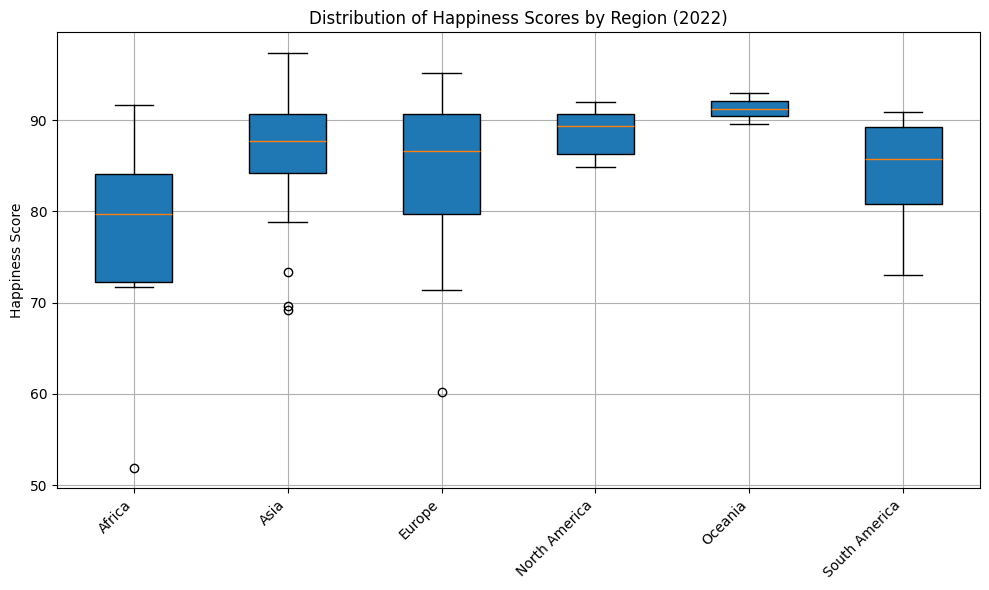

In [ ]:
plt.figure(figsize=(10, 6))
plt.boxplot(grouped.values, tick_labels=grouped.index, patch_artist=True)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Happiness Score')
plt.title('Distribution of Happiness Scores by Region (2022)')
plt.grid()
plt.tight_layout()
plt.show()


## 3.6 Pie Charts

**Purpose:** to show relative proportions or percentages of categories in a dataset.

**Common Use Cases:**

* Show the contribution of each part to a whole.
* Display a small number of categories relationship to others.
* Pie charts with many categories are usually not effective.

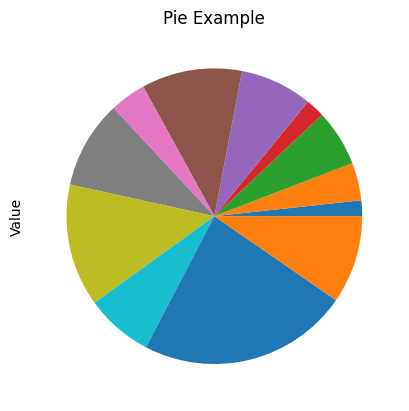

In [ ]:
values = [10, 24, 36, 12, 46, 64, 23, 56, 78, 43, 134, 56]

plt.pie(values)
plt.title("Pie Example")
plt.ylabel("Value")
plt.show()

### Use Case: Population by World Region

Using the same dataset as before, we can make a pie chart of population. We know there are a small number of regions, so this is well-suited for a pie chart.

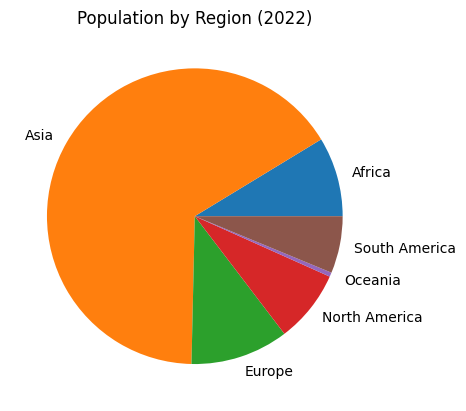

In [ ]:
regions = pd.DataFrame(my2022.groupby('World region according to OWID')['Population'].apply(list).apply(lambda x: sum(x)))
regions.reset_index(inplace=True)

plt.pie(regions['Population'], labels=regions['World region according to OWID'])
plt.title("Population by Region (2022)")
plt.show()


## 4. Customization & Aesthetics
You can change colors, line styles, markers, grids, annotations, and more to improve readability.

In [ ]:
fig, ax = plt.subplots()
x = [1, 2, 3, 4]
y = [10, 20, 25, 30]
ax.plot(x, y, linestyle='--', color='blue', marker='x', label='Sample')
ax.set_title("Customized Plot")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()
ax.grid(True)
ax.annotate("Peak", xy=(4, 30), xytext=(3.2, 28), arrowprops={'facecolor':'black', 'arrowstyle':'->'})
plt.show()


## 5. Subplots and Layouts
You can organize multiple plots into a grid using `plt.subplots()`.

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
axs[0, 0].plot(np.random.randn(100).cumsum())
axs[0, 0].set_title('Top Left')
axs[0, 1].bar(['A', 'B', 'C'], [5, 7, 3])
axs[0, 1].set_title('Top Right')
axs[1, 0].hist(np.random.randn(1000), bins=20)
axs[1, 0].set_title('Bottom Left')
axs[1, 1].scatter(np.random.rand(50), np.random.rand(50))
axs[1, 1].set_title('Bottom Right')
fig.tight_layout()
plt.show()

## 6. Exporting Figures
You can save your figures to files using `savefig()`.

In [ ]:
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [4, 5, 6])
fig.savefig("my_plot.png", dpi=300)
plt.close(fig)